Connected to base (Python 3.13.5)

Starting Stochastic Reconfiguration minimiser...
Effective Sample Size (ESS): 1372.2
iteration 0, x=[0.51484756 0.54245948 0.45551996], df = [-1.46524492  0.036031   -0.0119591 ],||d/df|| = 1.4657366538938665, 
N_s=100000, Natural grad update: [ 0.29695129  0.84918952 -0.88960077], alpha=0.05,
Local energy: -0.7066808376131443
Effective Sample Size (ESS): 2854.8
iteration 1, x=[0.52997317 0.58023768 0.41225466], df = [-1.50816545  0.04007025 -0.01415296],||d/df|| = 1.5087640521863181, 
N_s=100000, Natural grad update: [ 0.30251208  0.75556416 -0.86530602], alpha=0.05,
Local energy: -0.7223356850749628
Effective Sample Size (ESS): 3227.1
iteration 2, x=[0.54556402 0.63147576 0.41590636], df = [-1.38493636  0.03915318 -0.01456894],||d/df|| = 1.3855662908857602, 
N_s=100000, Natural grad update: [0.31181708 1.02476152 0.07303392], alpha=0.05,
Local energy: -0.7555630978240728
Effective Sample Size (ESS): 2979.1
iteration 3, x=[0.56114174 0.66473566 0.39129028], df = [-1.27252283  0.038775

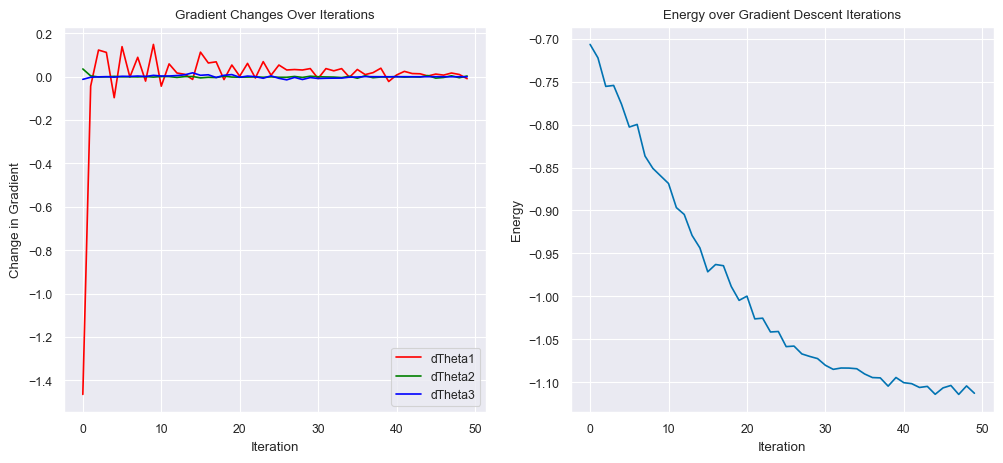

iteration number GD: 49
time elapsed GD: 259.1298796249994
final derivative: [-0.09289592  0.00551163 -0.00094315]
minimum theta: [1.03032052 0.20688747 1.20818301], minimum energy: -1.1128261525954835


In [ ]:
"""
Simulation of the hydrogen molecule using variational Monte Carlo methods.
Louis Liu 28/11
"""
import numpy as np
from modules.helpers import hydrogen_molecule_helpers as hlp
from modules.differentiators import double_central_difference
from modules.function_sampling import metropolis_hastings, MALA
from modules.minimisers import hydrogen_molecule_minimisers as minimisers
import matplotlib.pyplot as plt
eps = 1e-15


class h2_wavefunction:
    def __init__(self, thetas: np.ndarray, q1: np.ndarray, q2: np.ndarray):
        """
        Constructor
        Parameters:
            theta (np.ndarray): Variational parameters [theta1, theta2, theta3].
            q1 (np.ndarray): Position of the first nucleus.
            q2 (np.ndarray): Position of the second nucleus.
        """
        q1, q2 = np.array(q1), np.array(q2)
        if len(q1.shape) == 1:
            q1, q2 = np.asarray([q1]), np.asarray([q2])

        self.f = hlp.anstatz(thetas, q1, q2)
        self._thetas = thetas
        self._q1 = q1
        self._q2 = q2

    def psi(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray | float:
        """
        The trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray | float: The value of the trial wavefunction at the given position(s)
        """
        return self.f(r1, r2)

    def probability_density(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray | float:
        """
        The probability density of the trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray | float: The probability density at the given position(s)
        """
        return np.abs(self.f(r1, r2))**2

    def theta(self) -> np.ndarray:
        """
        Returns the theta parameter of the wavefunction
        Returns:
            float: the value of theta for the current wavefunction
        """
        return self._thetas

    def local_energy(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray:
        """
        The local energy of the hydrogen molecule trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray: The local energy at the given position(s)
        """

        r1, r2 = np.asarray(r1), np.asarray(r2)
        #  reformat
        if len(r1.shape) == 1:
            r1, r2 = np.asarray([r1]), np.asarray([r2])

        q1 = self._q1
        q2 = self._q2

        #  function to fix r2
        def f_r1(r1):
            return self.psi(r1, r2)

        #  function to fix r1
        def f_r2(r2):
            return self.psi(r1, r2)

        d2f_r1 = double_central_difference(
            f_r1, r1, h=[1e-5, 1e-5, 1e-5], order=8)

        d2f_r2 = double_central_difference(
            f_r2, r2, h=[1e-5, 1e-5, 1e-5], order=8)

        kinetic = - 0.5 / \
            self.psi(r1, r2) * (np.sum(d2f_r1, axis=1) +
                                np.sum(d2f_r2, axis=1))

        #  computes r and subtracts them
        def d(a, b): return np.sqrt(np.sum((a - b)**2, axis=1))

        r1q1, r1q2 = d(r1, q1), d(r1, q2)
        r2q1, r2q2 = d(r2, q1), d(r2, q2)
        r12 = d(r1, r2)
        q1q2 = d(q1, q2)

        potential = - (1/r1q1 + 1/r1q2 + 1/r2q1 + 1/r2q2) \
            + (1/r12) \
            + (1/q1q2)

        return kinetic + potential

    def E_exp(self, r1, r2):
        """
        The energy expecation value of the hydrogen molecule trial wavefunction at given coordinates
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray: The local energy at the given position(s)
        """
        r1, r2 = np.asarray(r1), np.asarray(r2)
        E_ls = self.local_energy(r1, r2)
        return np.mean(E_ls,)


def test_samples():
    q1 = [0, 2, 0]
    q2 = [0, 0, 0]
    wf = h2_wavefunction(thetas=[1., 1., 1.], q1=q1, q2=q2)

    def wrapper(coords):
        coords = np.asarray(coords)
        r1 = coords[:, 0:3]
        r2 = coords[:, 3:6]

        return wf.probability_density(r1, r2)

    def wrapper_grad(coords):
        from modules.differentiators import central_difference

        coords = np.asarray(coords)
        grad = central_difference(wrapper, coords, h=[1e-4]*6, order=2)
        return np.sum(grad, axis=0)

    x_0 = np.ones(6, dtype=float)
    N_s = 1000000
    samples = MALA(wrapper, wrapper_grad, x_0=x_0, N=N_s,
                   timestep=0.5, xmin=-10., xmax=10., detail=True)

    # samples = metropolis_hastings(
    #     wrapper, f_prop='gaussian', x_0=x_0, xmax=10., xmin=-10., N=N_s, kwrgs={
    #         'sigma': 0.7}, detail=True)

    print('Finished Sampling')

    r1, r2 = samples[:, 0:3], samples[:, 3:6]
    E_l = wf.local_energy(r1=r1, r2=r2)

    plt.scatter(np.linalg.norm(r1, axis=1), E_l, marker='.', alpha=0.1)
    plt.plot(0, q1[1], 'ro', label='Nucleus 1')
    plt.plot(0, q2[1], 'bo', label='Nucleus 2')
    plt.xlabel("Distance of electron 1 from origin")
    plt.ylabel("Local Energy")
    plt.title("Local energy vs distance of electron 1 from origin")
    plt.show()

    print(f"local energy: {E_l}")
    exp_energy = np.mean(E_l)
    print(f"Expected Energy: {exp_energy}")

    hlp.plot_samples(
        r1, r2, q1=q1, q2=q2, xlim=[-3, 3], ylim=[-3, 3], seaborn=False)
    plt.show()


def test_minimiser():
    q1 = [0, 0, 2]
    q2 = [0, 0, 0]

    minimiser = minimisers.stochastic_reconfiguration

    N_s = 100000
    thetas_0 = [.5] * 3  #  for minimiser
    theta_min, E_min = minimiser(q1, q2, x_0=thetas_0,
                                 alpha=0.05, stop_tol=1e-3, N_s=N_s, detail=True, max_iter=50)

    # theta_min, E_min = minimisers.simulated_annealing(
    #     q1, q2, x_0=thetas_0, initial_temp=0.5, cooling_rate=0.95, max_iter=200, Ns=10000, std=0.05, detail=True)
    print(f"minimum theta: {theta_min}, minimum energy: {E_min}")


def ground_state_energies():
    Ns = 100000
    r_0 = np.linspace(0.5, 3., 100)
    q1 = [0.] * 3
    q2 = [[0., 0., i] for i in r_0]

    energies = []
    count = 0
    for q2_i in q2:
        count += 1
        thetas_0 = [1.]*3  #  for minimiser
        theta_min, E_min = minimisers.simulated_annealing(
            q1, q2_i, x_0=thetas_0, initial_temp=0.5, cooling_rate=0.95, max_iter=200, Ns=Ns, std=0.05, detail=False)

        # theta_min, E_min = minimisers.stochastic_reconfiguration(
        #     q1, q2_i, x_0=thetas_0, alpha=0.02, stop_tol=1e-3, N_s=Ns, detail=False, max_iter=50)
        energies.append(E_min)
        if count % 10 == 0:  #  checkpoint at every 10 steps
            np.savetxt(f"SA_output_{Ns}.txt", [energies, r_0[:len(energies)]])

        print(
            f"iteration: {count}, q2: {q2_i}, minimum theta: {theta_min}, minimum energy: {E_min}")

    np.savetxt(f"SA_output_{Ns}.txt", [energies, r_0[:len(energies)]])
    energies = np.array(energies)
    from scipy.optimize import curve_fit
    f = hlp.V_morse
    p_0 = [0.25, 1.3, 1.4]
    fit, cov = curve_fit(f, r_0, energies, p0=p_0)

    plt.plot(r_0, f(r_0, *fit), label='Morse Potential Fit', color='orange')
    plt.plot(r_0, energies, 'o', label='Data')
    plt.xlabel("Distance between nuclei (a.u.)")
    plt.ylabel("Minimum Energy (a.u.)")
    plt.title("Morse Potential Fit to H2 Minimum Energy")
    plt.legend()
    print(
        f"Fitted Parameters: De= {fit[0]}, a= {fit[1]}, re= {fit[2]} \n errors: {np.sqrt(np.diag(cov))}")


if __name__ == '__main__':
    test_minimiser()

In [ ]:
print("stochastic reconfiguration stepsize 0.05")

stochastic reconfiguration stepsize 0.05


Starting Stochastic Reconfiguration minimiser...
Effective Sample Size (ESS): 2707.6
iteration 0, x=[0.56030697 0.64984827 0.28127932], df = [-1.40507505  0.03620401 -0.01173596],||d/df|| = 1.4055903989930576, 
N_s=100000, Natural grad update: [ 0.30153484  0.74924137 -1.09360341], alpha=0.2,
Local energy: -0.7087875168040028
Effective Sample Size (ESS): 2793.8
iteration 1, x=[0.6251951  0.85449604 0.16612405], df = [-1.26771288  0.04034272 -0.0082488 ],||d/df|| = 1.2683814573562553, 
N_s=100000, Natural grad update: [ 0.32444066  1.02323883 -0.57577633], alpha=0.2,
Local energy: -0.7758231065442873
Effective Sample Size (ESS): 2952.4
iteration 2, x=[0.68822821 1.07989329 0.08534483], df = [-1.12378889  0.03803086  0.03606026],||d/df|| = 1.1250102882381388, 
N_s=100000, Natural grad update: [ 0.31516556  1.12698623 -0.4038961 ], alpha=0.2,
Local energy: -0.8532161945482559
Effective Sample Size (ESS): 3131.0
iteration 3, x=[0.75348668 1.1617758  0.09765216], df = [-0.97092664  0.026582

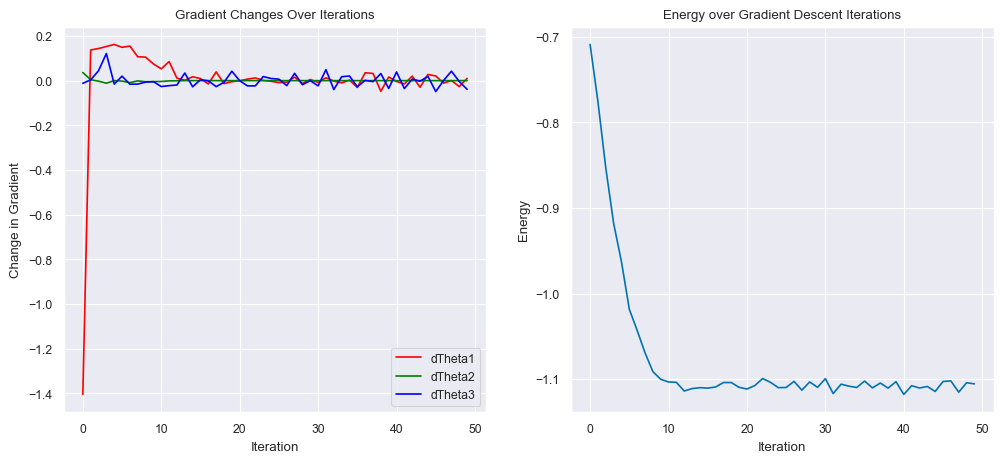

iteration number GD: 49
time elapsed GD: 311.6740785840002
final derivative: [-3.05934351e-02  2.04353483e-09  1.90441302e-02]
minimum theta: [1.05475316e+00 9.31921719e-01 1.00000000e-07], minimum energy: -1.105635105671547


In [ ]:
"""
Simulation of the hydrogen molecule using variational Monte Carlo methods.
Louis Liu 28/11
"""
import numpy as np
from modules.helpers import hydrogen_molecule_helpers as hlp
from modules.differentiators import double_central_difference
from modules.function_sampling import metropolis_hastings, MALA
from modules.minimisers import hydrogen_molecule_minimisers as minimisers
import matplotlib.pyplot as plt
eps = 1e-15


class h2_wavefunction:
    def __init__(self, thetas: np.ndarray, q1: np.ndarray, q2: np.ndarray):
        """
        Constructor
        Parameters:
            theta (np.ndarray): Variational parameters [theta1, theta2, theta3].
            q1 (np.ndarray): Position of the first nucleus.
            q2 (np.ndarray): Position of the second nucleus.
        """
        q1, q2 = np.array(q1), np.array(q2)
        if len(q1.shape) == 1:
            q1, q2 = np.asarray([q1]), np.asarray([q2])

        self.f = hlp.anstatz(thetas, q1, q2)
        self._thetas = thetas
        self._q1 = q1
        self._q2 = q2

    def psi(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray | float:
        """
        The trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray | float: The value of the trial wavefunction at the given position(s)
        """
        return self.f(r1, r2)

    def probability_density(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray | float:
        """
        The probability density of the trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray | float: The probability density at the given position(s)
        """
        return np.abs(self.f(r1, r2))**2

    def theta(self) -> np.ndarray:
        """
        Returns the theta parameter of the wavefunction
        Returns:
            float: the value of theta for the current wavefunction
        """
        return self._thetas

    def local_energy(self, r1: np.ndarray, r2: np.ndarray) -> np.ndarray:
        """
        The local energy of the hydrogen molecule trial wavefunction
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray: The local energy at the given position(s)
        """

        r1, r2 = np.asarray(r1), np.asarray(r2)
        #  reformat
        if len(r1.shape) == 1:
            r1, r2 = np.asarray([r1]), np.asarray([r2])

        q1 = self._q1
        q2 = self._q2

        #  function to fix r2
        def f_r1(r1):
            return self.psi(r1, r2)

        #  function to fix r1
        def f_r2(r2):
            return self.psi(r1, r2)

        d2f_r1 = double_central_difference(
            f_r1, r1, h=[1e-5, 1e-5, 1e-5], order=8)

        d2f_r2 = double_central_difference(
            f_r2, r2, h=[1e-5, 1e-5, 1e-5], order=8)

        kinetic = - 0.5 / \
            self.psi(r1, r2) * (np.sum(d2f_r1, axis=1) +
                                np.sum(d2f_r2, axis=1))

        #  computes r and subtracts them
        def d(a, b): return np.sqrt(np.sum((a - b)**2, axis=1))

        r1q1, r1q2 = d(r1, q1), d(r1, q2)
        r2q1, r2q2 = d(r2, q1), d(r2, q2)
        r12 = d(r1, r2)
        q1q2 = d(q1, q2)

        potential = - (1/r1q1 + 1/r1q2 + 1/r2q1 + 1/r2q2) \
            + (1/r12) \
            + (1/q1q2)

        return kinetic + potential

    def E_exp(self, r1, r2):
        """
        The energy expecation value of the hydrogen molecule trial wavefunction at given coordinates
        Parameters:
            r1: np.ndarray, The position(s) of electron 1 as an array of shape (N, 3)
            r2: np.ndarray, The position(s) of electron 2 as an array of shape (N, 3)
        Returns:
            np.ndarray: The local energy at the given position(s)
        """
        r1, r2 = np.asarray(r1), np.asarray(r2)
        E_ls = self.local_energy(r1, r2)
        return np.mean(E_ls,)


def test_samples():
    q1 = [0, 2, 0]
    q2 = [0, 0, 0]
    wf = h2_wavefunction(thetas=[1., 1., 1.], q1=q1, q2=q2)

    def wrapper(coords):
        coords = np.asarray(coords)
        r1 = coords[:, 0:3]
        r2 = coords[:, 3:6]

        return wf.probability_density(r1, r2)

    def wrapper_grad(coords):
        from modules.differentiators import central_difference

        coords = np.asarray(coords)
        grad = central_difference(wrapper, coords, h=[1e-4]*6, order=2)
        return np.sum(grad, axis=0)

    x_0 = np.ones(6, dtype=float)
    N_s = 1000000
    samples = MALA(wrapper, wrapper_grad, x_0=x_0, N=N_s,
                   timestep=0.5, xmin=-10., xmax=10., detail=True)

    # samples = metropolis_hastings(
    #     wrapper, f_prop='gaussian', x_0=x_0, xmax=10., xmin=-10., N=N_s, kwrgs={
    #         'sigma': 0.7}, detail=True)

    print('Finished Sampling')

    r1, r2 = samples[:, 0:3], samples[:, 3:6]
    E_l = wf.local_energy(r1=r1, r2=r2)

    plt.scatter(np.linalg.norm(r1, axis=1), E_l, marker='.', alpha=0.1)
    plt.plot(0, q1[1], 'ro', label='Nucleus 1')
    plt.plot(0, q2[1], 'bo', label='Nucleus 2')
    plt.xlabel("Distance of electron 1 from origin")
    plt.ylabel("Local Energy")
    plt.title("Local energy vs distance of electron 1 from origin")
    plt.show()

    print(f"local energy: {E_l}")
    exp_energy = np.mean(E_l)
    print(f"Expected Energy: {exp_energy}")

    hlp.plot_samples(
        r1, r2, q1=q1, q2=q2, xlim=[-3, 3], ylim=[-3, 3], seaborn=False)
    plt.show()


def test_minimiser():
    q1 = [0, 0, 2]
    q2 = [0, 0, 0]

    minimiser = minimisers.stochastic_reconfiguration

    N_s = 100000
    thetas_0 = [.5] * 3  #  for minimiser
    theta_min, E_min = minimiser(q1, q2, x_0=thetas_0,
                                 alpha=0.2, stop_tol=1e-3, N_s=N_s, detail=True, max_iter=50)

    # theta_min, E_min = minimisers.simulated_annealing(
    #     q1, q2, x_0=thetas_0, initial_temp=0.5, cooling_rate=0.95, max_iter=200, Ns=10000, std=0.05, detail=True)
    print(f"minimum theta: {theta_min}, minimum energy: {E_min}")


def ground_state_energies():
    Ns = 100000
    r_0 = np.linspace(0.5, 3., 100)
    q1 = [0.] * 3
    q2 = [[0., 0., i] for i in r_0]

    energies = []
    count = 0
    for q2_i in q2:
        count += 1
        thetas_0 = [1.]*3  #  for minimiser
        theta_min, E_min = minimisers.simulated_annealing(
            q1, q2_i, x_0=thetas_0, initial_temp=0.5, cooling_rate=0.95, max_iter=200, Ns=Ns, std=0.05, detail=False)

        # theta_min, E_min = minimisers.stochastic_reconfiguration(
        #     q1, q2_i, x_0=thetas_0, alpha=0.02, stop_tol=1e-3, N_s=Ns, detail=False, max_iter=50)
        energies.append(E_min)
        if count % 10 == 0:  #  checkpoint at every 10 steps
            np.savetxt(f"SA_output_{Ns}.txt", [energies, r_0[:len(energies)]])

        print(
            f"iteration: {count}, q2: {q2_i}, minimum theta: {theta_min}, minimum energy: {E_min}")

    np.savetxt(f"SA_output_{Ns}.txt", [energies, r_0[:len(energies)]])
    energies = np.array(energies)
    from scipy.optimize import curve_fit
    f = hlp.V_morse
    p_0 = [0.25, 1.3, 1.4]
    fit, cov = curve_fit(f, r_0, energies, p0=p_0)

    plt.plot(r_0, f(r_0, *fit), label='Morse Potential Fit', color='orange')
    plt.plot(r_0, energies, 'o', label='Data')
    plt.xlabel("Distance between nuclei (a.u.)")
    plt.ylabel("Minimum Energy (a.u.)")
    plt.title("Morse Potential Fit to H2 Minimum Energy")
    plt.legend()
    print(
        f"Fitted Parameters: De= {fit[0]}, a= {fit[1]}, re= {fit[2]} \n errors: {np.sqrt(np.diag(cov))}")


if __name__ == '__main__':
    test_minimiser()

In [ ]:
print("stochastic reconfiguration stepsize 0.2")

stochastic reconfiguration stepsize 0.2
